todos: 

(1) an make some transect plots to see how the plume moves offshore and in the vertical 

(2) quantify the amount of tracer that remains in the surface ocean over time. So adding up the amount of tracer in say the top 100 meters or so and plotting a time series of each simulation
      - when doing the latter, have to do it carefully. The model sees the tracers as a concentration. So to get mass you have multiply by the volume. and you have to do that at each grid cell. And you can’t just assume all the grid cells are the same size, a 1 degree x 1 degree box occupies less and less space as you move away from the equator

In [1]:
using CairoMakie
using Oceananigans
using Oceananigans.Units
using Oceananigans.ImmersedBoundaries: mask_immersed_field!

In [2]:

# array dimensions are long x lat x depth 
# retrieve fieldtimeseries from original simulation 
dye_on = FieldTimeSeries(
    "amazon_rivers_on_dye_3d.jld2",
    "dye";
    backend = OnDisk()
)

dye_off = FieldTimeSeries(
    "amazon_rivers_off_dye_3d.jld2",
    "dye";
    backend = OnDisk()
)

170×170×20×181 FieldTimeSeries{OnDisk} located at (Center, Center, Center) of dye at amazon_rivers_off_dye_3d.jld2
├── grid: 170×170×20 ImmersedBoundaryGrid{Float64, Bounded, Bounded, Bounded} on CPU with 5×5×4 halo
├── indices: (:, :, :)
├── time_indexing: Linear()
├── backend: OnDisk
├── path: amazon_rivers_off_dye_3d.jld2
└── name: dye

In [3]:

# the days we want to compare transects across 
target_days = [420,480, 540]

# find the physical coordinates of the dye in each cell (use center() because it's stored there)
λ, φ, z = nodes(
    dye_on.grid,
    Center(),
    Center(),
    Center()
)

# nodes returned special packaged grid containers by oceanangians --> hard to analyze 
# collect stores their values as standard vectors for further analysis 
λ = collect(λ)
φ = collect(φ)
z = collect(z)

# load model bathymetry
bottom_height = Array( # transfer to a normal array 
    interior( # remove halo cells 
        dye_on.grid.immersed_boundary.bottom_height # pull the botom seafloor cells 
    )
)

170×170×1 Array{Float64, 3}:
[:, :, 1] =
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -2161.57  -2161.57  -2161.57
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2161.57  -2161.57  -2161.57
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2161.57  -2161.57  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  …  -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0     -2656.68  -2656.68  -2656.68
 0.0  0.0  0.0  0.0  0.

In [4]:
# this function extracts one 2d transect from a complete 3d dye field
function extract_transect(
    dye_3d,
    bottom_height,
    orientation,
    fixed_idx
)
    # if e-w, hold latitude constant 
    if orientation == :east_west
        # copy creates an independent horizontal-position × depth array
        transect = copy(
            # keep every longitude, keep one latitude (specified), keep every vertical level 
            dye_3d[:, fixed_idx, :]
        )

        # extract the seafloor along the same fixed latitude
        transect_bottom = copy(
            bottom_height[:, fixed_idx]
        )

    #  if n-s, hold longitude constant
    elseif orientation == :north_south
        transect = copy(
            # keep one longitude, keep every latitude, keep every vertical level 
            dye_3d[fixed_idx, :, :]
        )
        
        # extract bathymetry along fixed longitude
        transect_bottom = copy(
            bottom_height[fixed_idx, :]
        )
    end
    
    # return both the dye section and its matching bottom profile
    return transect, transect_bottom
end


extract_transect (generic function with 1 method)

In [5]:
# Prepare two already-masked transects for plotting.
function prepare_multitime_transect(transect_on, transect_off)

    # log scale
    log_on = log10.(max.(transect_on, 0.0) .+ 1e-16)
    log_off = log10.(max.(transect_off, 0.0) .+ 1e-16)

    # calculate freshwater-on minus freshwater-off concentration.
    difference = transect_on .- transect_off

    return log_on, log_off, difference
end

prepare_multitime_transect (generic function with 1 method)

In [6]:
# loads the requested times, calls the two helper functions + creates the complete figure
function plot_transect_over_time(
    dye_on,
    dye_off,
    bottom_height,
    λ,
    φ,
    z,
    target_days;
    orientation,
    fixed_coordinate,
    transect_name,
    filename
)
    # determine the nearest grid coordinate for an east-west transect
    if orientation == :east_west
        # find the latitude index closest to the requested latitude
        fixed_idx = argmin(
            abs.(φ .- fixed_coordinate)
        )

        # record the actual model latitude selected
        actual_coordinate =
            φ[fixed_idx]

        # longitude varies along an east-west transect
        horizontal_coordinate = λ

        # label the horizontal axis as longitude
        horizontal_label =
            "Longitude (°E)"

        # create coordinate text such as 2.05°N
        coordinate_text = string(
            round(
                actual_coordinate;
                digits = 2
            ),
            "°N"
        )

    # determine the nearest grid coordinate for a north-south transect
    elseif orientation == :north_south
        # find the longitude index closest to the requested longitude
        fixed_idx = argmin(
            abs.(
                λ .- fixed_coordinate
            )
        )

        # record the actual model longitude selected
        actual_coordinate =
            λ[fixed_idx]
        # latitude varies along a north-south transect
        horizontal_coordinate = φ
        horizontal_label =
            "Latitude (°N)"
        # create coordinate text such as -49.55°E
        coordinate_text = string(
            round(actual_coordinate;digits = 2),"°E")
    end

    # create containers for the prepared arrays from each requested day
    log_on_by_day = Any[]
    log_off_by_day = Any[]
    difference_by_day = Any[]
    bottom_by_day = Any[]

    # record the actual times selected from each file
    actual_days_on = Float64[]
    actual_days_off = Float64[]

    # repeat the loading + transect preparation for every target day
    for target_day in target_days
        # find the freshwater-on/off output closest to the requested day
        time_idx_on = argmin(abs.(dye_on.times ./ days .- target_day))
        time_idx_off = argmin(abs.(dye_off.times ./ days .- target_day))

        # record actual freshwater-on/freshwater-off output day
        push!(actual_days_on, dye_on.times[time_idx_on] / days)
        push!(actual_days_off,dye_off.times[time_idx_off] / days)

        # Load the snapshots as Oceananigans Fields.
        field_on = dye_on[time_idx_on]
        field_off = dye_off[time_idx_off]

        # Use the grid's immersed boundary to replace inactive cells with NaN.
        mask_immersed_field!(field_on, NaN)
        mask_immersed_field!(field_off, NaN)

        # Convert the masked Fields into ordinary arrays for transect extraction.
        dye_on_3d = Array(interior(field_on))
        dye_off_3d = Array(interior(field_off))

        # extract the freshwater-on transect + its seafloor profile
        transect_on, transect_bottom = extract_transect(dye_on_3d, bottom_height, orientation, fixed_idx)

        # extract the same transect from freshwater off
        # ignore the repeated seafloor because both simulations use the same grid
        transect_off, _ = extract_transect(dye_off_3d, bottom_height, orientation, fixed_idx)

        # function 2 masks inactive cells + calculates the log concentrations and difference
        log_on, log_off, difference = prepare_multitime_transect(transect_on, transect_off)
        # store the prepared results in chronological order
        push!(log_on_by_day, log_on)
        push!(log_off_by_day, log_off)
        push!(difference_by_day, difference)
        push!(bottom_by_day, transect_bottom)
    end

    # find the largest absolute difference across every valid cell + day
    # one shared limit makes all three difference panels comparable
    difference_limit = 0.0

    for difference in difference_by_day
        for value in difference
            if isfinite(value)
                difference_limit = max(difference_limit, abs(value))
            end
        end
    end

    # prevent an invalid zero-width color range if both fields are identical
    if difference_limit == 0
        difference_limit = 1e-16
    end

    # create the figure + add one title across the three time columns
    figure = Figure(size = (1550, 1100))
    Label(figure[0, 1:3], "$(transect_name) at $(coordinate_text)"; fontsize = 24, font = :bold)

    # store every axis for linked limits + heatmap handles for shared colorbars
    all_axes = Axis[]
    concentration_plot = nothing
    difference_plot = nothing

    # create one column for every requested day
    for column in eachindex(target_days)
        target_day = target_days[column]

        # row 1 shows freshwater forcing on
        axis_on = Axis(figure[1, column], title = "Day $(target_day)", ylabel = "Freshwater on\nDepth (m)")
        current_concentration_plot = heatmap!(axis_on, horizontal_coordinate, z, log_on_by_day[column];
                                              colorrange = (-8, 0), colormap = :viridis, nan_color = :lightgray)
        lines!(axis_on, horizontal_coordinate, bottom_by_day[column]; color = :black, linewidth = 1.5)

        # row 2 shows freshwater forcing off using the same concentration scale
        axis_off = Axis(figure[2, column], ylabel = "Freshwater off\nDepth (m)")
        heatmap!(axis_off, horizontal_coordinate, z, log_off_by_day[column];
                 colorrange = (-8, 0), colormap = :viridis, nan_color = :lightgray)
        lines!(axis_off, horizontal_coordinate, bottom_by_day[column]; color = :black, linewidth = 1.5)

        # row 3 shows freshwater on minus freshwater off
        axis_difference = Axis(figure[3, column], xlabel = horizontal_label, ylabel = "On - off\nDepth (m)")
        current_difference_plot = heatmap!(axis_difference, horizontal_coordinate, z, difference_by_day[column];
                                           colorrange = (-difference_limit, difference_limit),
                                           colormap = :balance, nan_color = :lightgray)
        lines!(axis_difference, horizontal_coordinate, bottom_by_day[column]; color = :black, linewidth = 1.5)

        ylims!(axis_on, -100, 0)
        ylims!(axis_off, -100, 0)
        ylims!(axis_difference, -100, 0)

        # remove repeated horizontal labels from the upper two rows
        hidexdecorations!(axis_on; grid = false)
        hidexdecorations!(axis_off; grid = false)

        # store the axes so all panels can receive identical limits
        push!(all_axes, axis_on, axis_off, axis_difference)

        # retain the first heatmap handles for the shared colorbars
        if column == 1
            concentration_plot = current_concentration_plot
            difference_plot = current_difference_plot
        end
    end

    # give every panel identical horizontal + vertical limits
    linkxaxes!(all_axes...)
    linkyaxes!(all_axes...)

    # add the shared log-concentration and linear-difference colorbars
    Colorbar(figure[1:2, 4], concentration_plot; label = "log₁₀(dye concentration + 1e-16)")
    Colorbar(figure[3, 4], difference_plot; label = "Dye concentration difference")

    # save the completed figure
    save(filename, figure)

    # print the selected coordinate, times, difference range + filename
    println(transect_name)
    println("  requested coordinate: ", fixed_coordinate)
    println("  selected coordinate: ", coordinate_text)
    println("  freshwater-on days: ", actual_days_on)
    println("  freshwater-off days: ", actual_days_off)
    println("  difference range: ±", difference_limit)
    println("  saved as: ", filename)

    # return the figure so it can be displayed in the notebook
    return figure
end

plot_transect_over_time (generic function with 1 method)

Offshore east-west transect
  requested coordinate: 2.0
  selected coordinate: 2.05°N
  freshwater-on days: [420.0, 480.0, 540.0]
  freshwater-off days: [420.0, 480.0, 540.0]
  difference range: ±0.06208239495754242
  saved as: amazon_dye_transect_2N_days_0_30_60.png


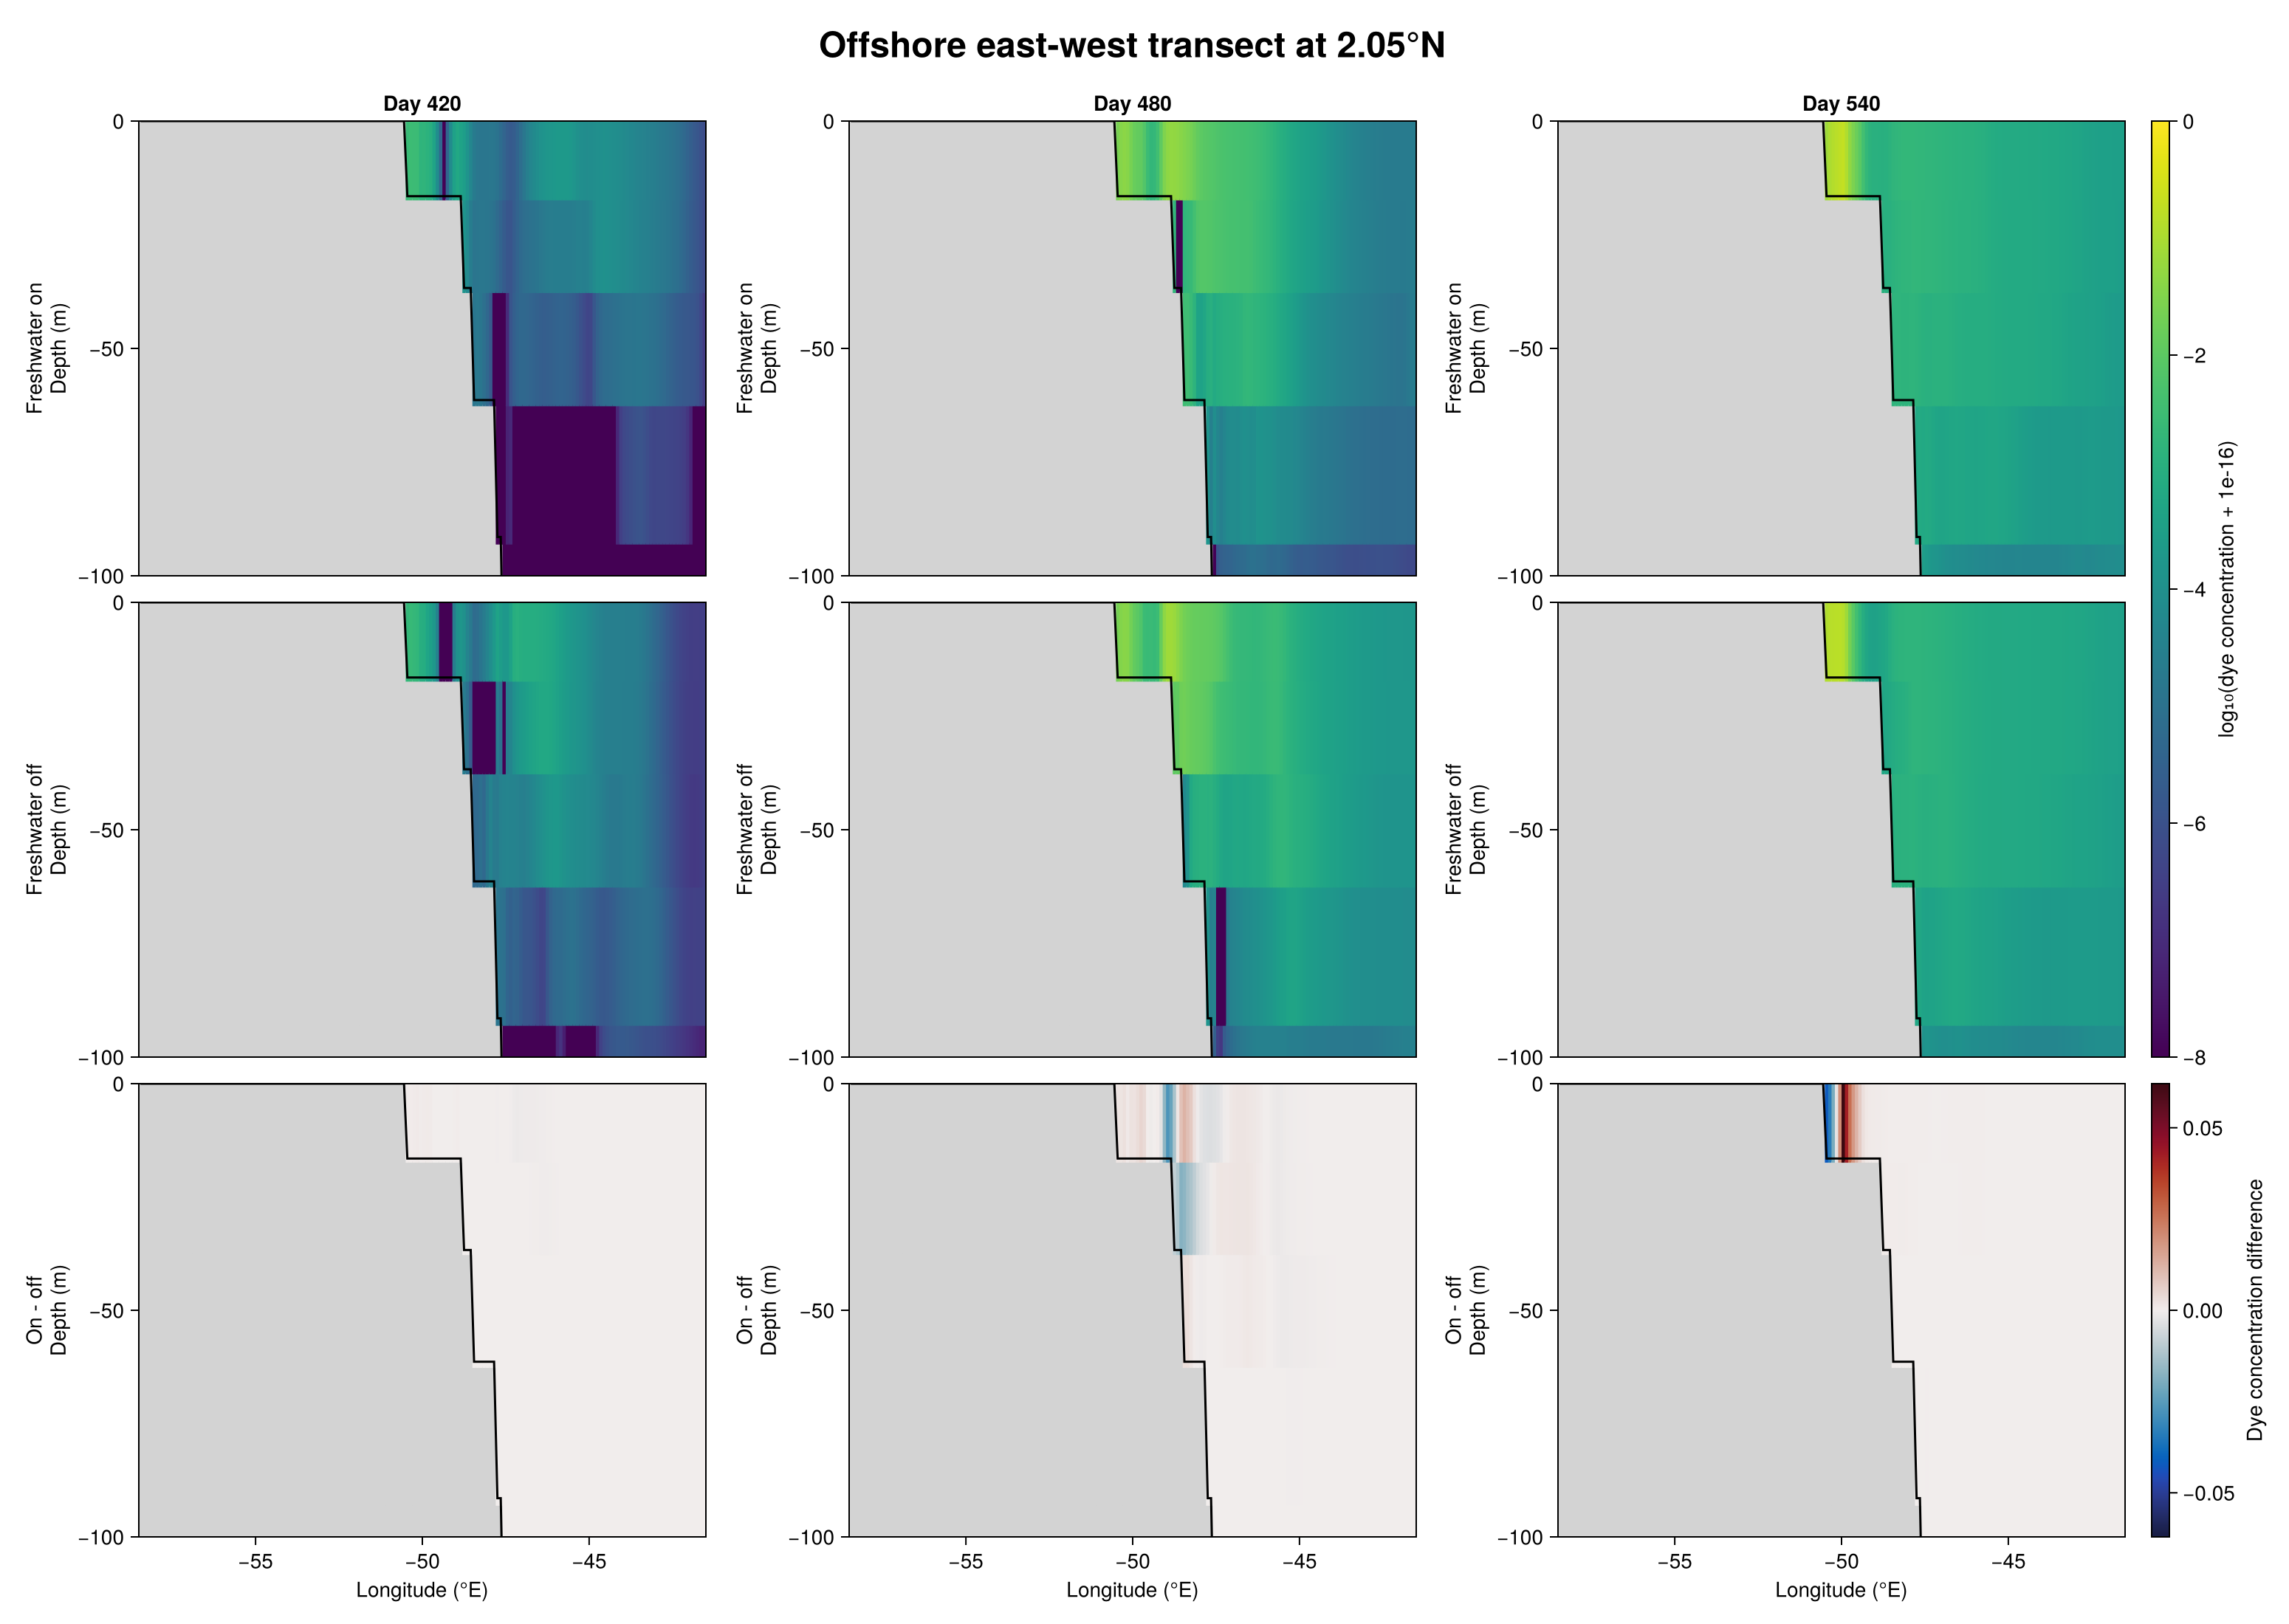

Downstream east-west transect
  requested coordinate: 3.0
  selected coordinate: 3.05°N
  freshwater-on days: [420.0, 480.0, 540.0]
  freshwater-off days: [420.0, 480.0, 540.0]
  difference range: ±0.0558411106467247
  saved as: amazon_dye_transect_3N_days_0_30_60.png


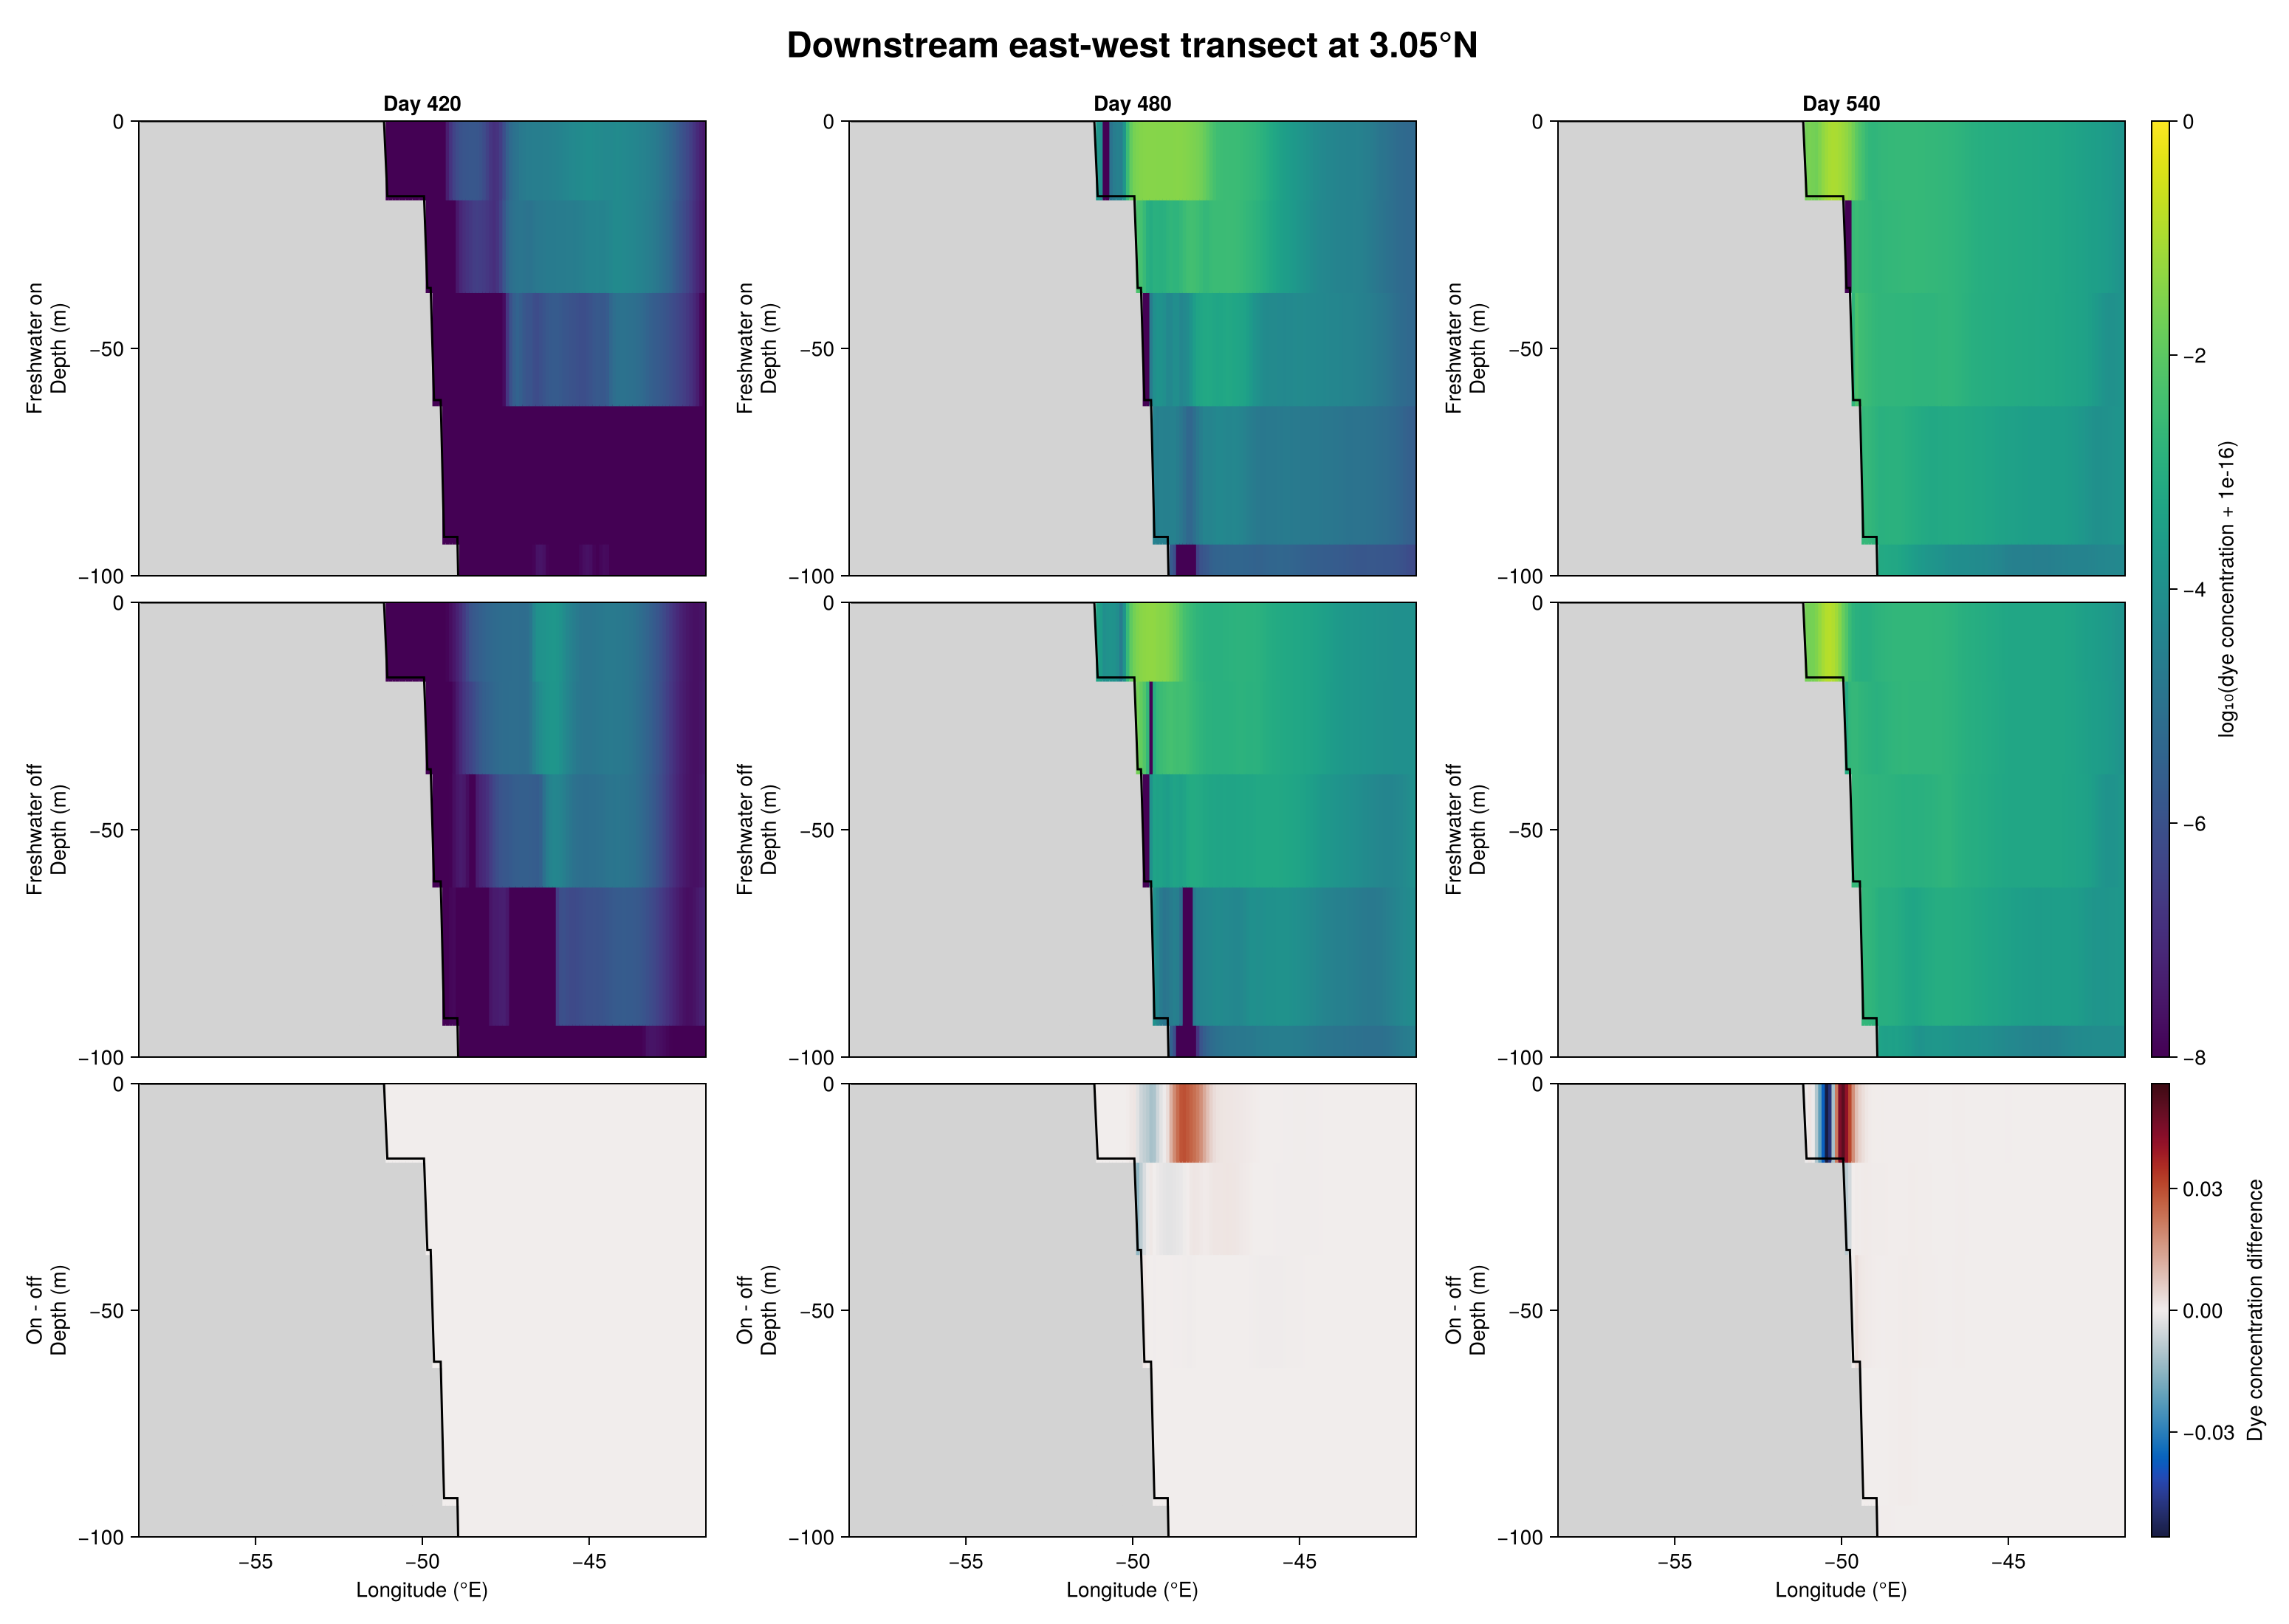

CairoMakie.Screen{IMAGE}


In [7]:
# create + display the offshore east-west transect at approximately 2°N
east_west_2N_figure = plot_transect_over_time(
    dye_on, dye_off, bottom_height, λ, φ, z, target_days;
    orientation = :east_west,
    fixed_coordinate = 2.0,
    transect_name = "Offshore east-west transect",
    filename = "amazon_dye_transect_2N_days_0_30_60.png"
)
display(east_west_2N_figure)

# create + display the downstream east-west transect at approximately 3°N
east_west_3N_figure = plot_transect_over_time(
    dye_on, dye_off, bottom_height, λ, φ, z, target_days;
    orientation = :east_west,
    fixed_coordinate = 3.0,
    transect_name = "Downstream east-west transect",
    filename = "amazon_dye_transect_3N_days_0_30_60.png"
)
display(east_west_3N_figure)


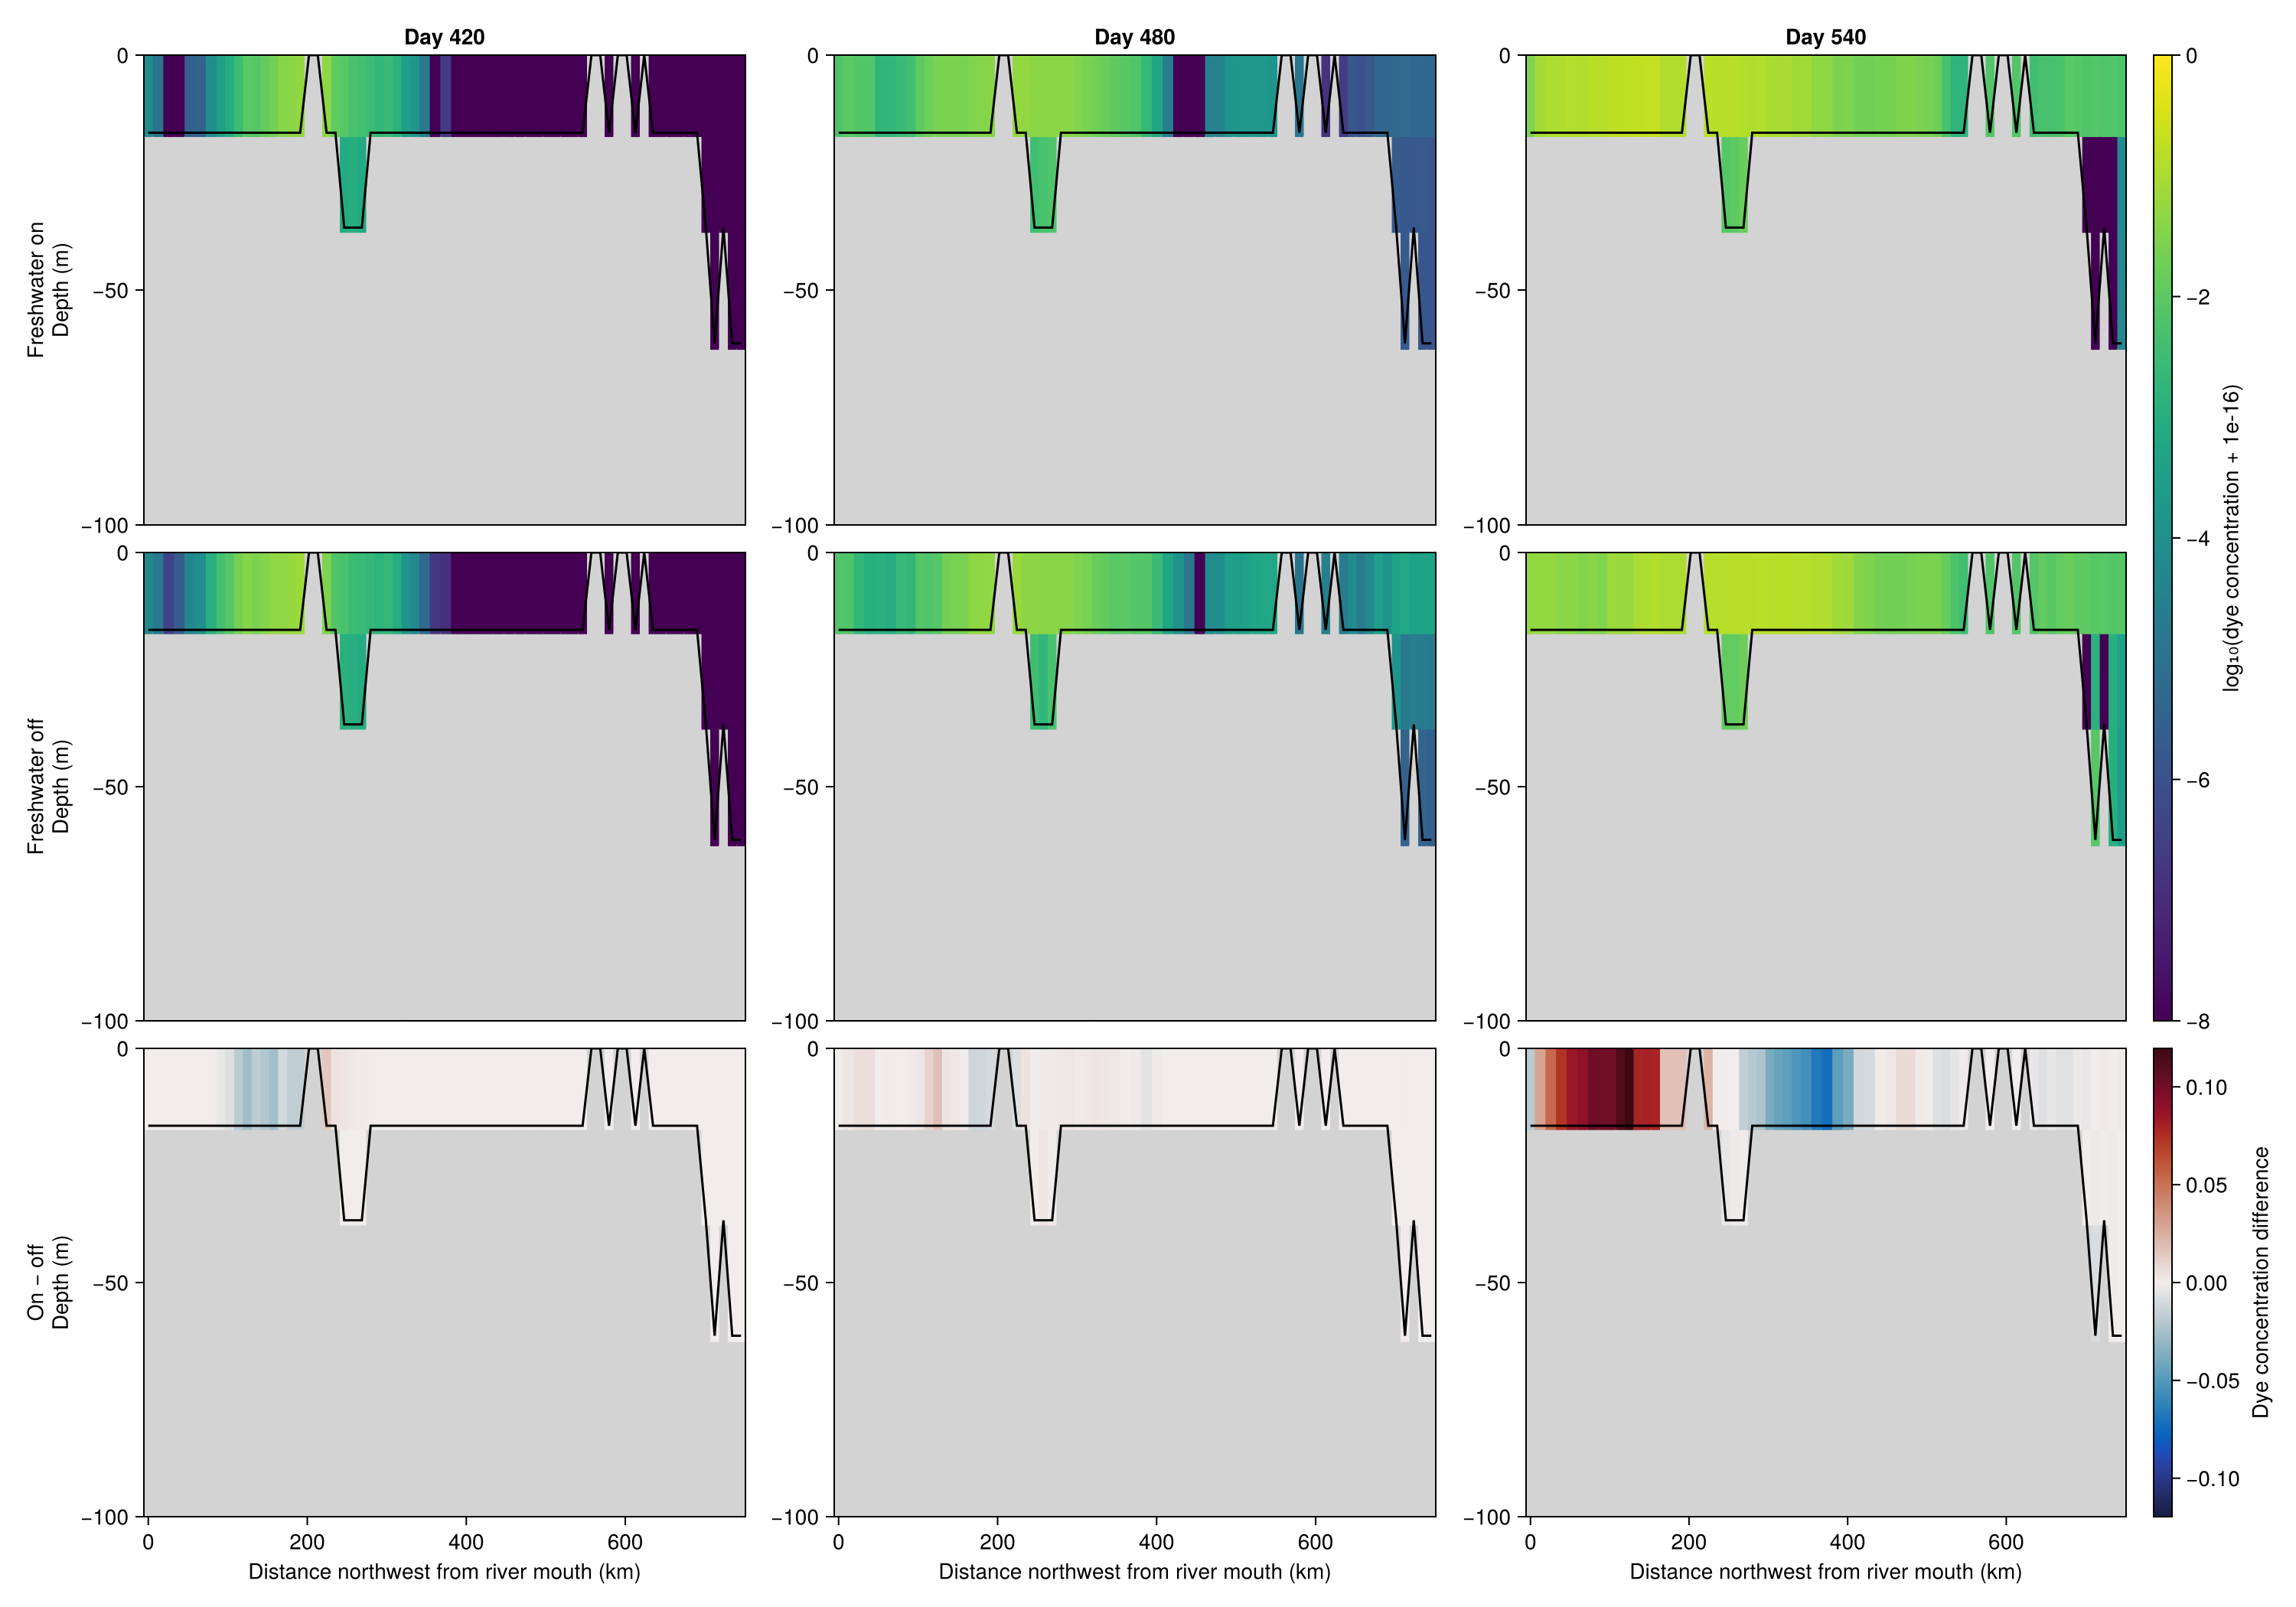

In [8]:
# along-coast transect

mouth_lon, mouth_lat = -49.35, 0.30
end_lon, end_lat = -51.80, 5.00

path_lon = range(mouth_lon, end_lon; length = 120)
path_lat = range(mouth_lat, end_lat; length = 120)

cells = unique([
    (
        argmin(abs.(λ .- path_lon[p])),
        argmin(abs.(φ .- path_lat[p]))
    )
    for p in eachindex(path_lon)
])

path_i = first.(cells)
path_j = last.(cells)

selected_lon = λ[path_i]
selected_lat = φ[path_j]
npoints = length(path_i)

distance_km = zeros(npoints)

for p in 2:npoints
    mean_lat = deg2rad((selected_lat[p] + selected_lat[p-1]) / 2)
    dx = 111.32 * cos(mean_lat) * (selected_lon[p] - selected_lon[p-1])
    dy = 110.57 * (selected_lat[p] - selected_lat[p-1])

    distance_km[p] = distance_km[p-1] + hypot(dx, dy)
end

transect_bottom = [
    bottom_height[path_i[p], path_j[p], 1]
    for p in 1:npoints
]

log_on_by_day = Any[]
log_off_by_day = Any[]
difference_by_day = Any[]
actual_days = Float64[]

for target_day in target_days
    time_idx_on = argmin(abs.(dye_on.times ./ days .- target_day))
    time_idx_off = argmin(abs.(dye_off.times ./ days .- target_day))

    push!(actual_days, dye_on.times[time_idx_on] / days)

    field_on = dye_on[time_idx_on]
    field_off = dye_off[time_idx_off]

    mask_immersed_field!(field_on, NaN)
    mask_immersed_field!(field_off, NaN)

    d_on = Array(interior(field_on))
    d_off = Array(interior(field_off))

    transect_on = fill(NaN, npoints, length(z))
    transect_off = fill(NaN, npoints, length(z))

    for p in 1:npoints
        transect_on[p, :] .= d_on[path_i[p], path_j[p], :]
        transect_off[p, :] .= d_off[path_i[p], path_j[p], :]
    end

    log_on, log_off, difference =
        prepare_multitime_transect(transect_on, transect_off)

    push!(log_on_by_day, log_on)
    push!(log_off_by_day, log_off)
    push!(difference_by_day, difference)
end

valid_differences = filter(
    isfinite,
    reduce(vcat, vec.(difference_by_day))
)

if isempty(valid_differences)
    difference_limit = 1e-16
else
    difference_limit = maximum(abs.(valid_differences))
    difference_limit = max(difference_limit, 1e-16)
end

fig = Figure(size = (1500, 1050))

all_axes = Axis[]
concentration_plot = nothing
difference_plot = nothing

for column in eachindex(target_days)
    ylabel_on = ""
    ylabel_off = ""
    ylabel_difference = ""

    if column == 1
        ylabel_on = "Freshwater on\nDepth (m)"
        ylabel_off = "Freshwater off\nDepth (m)"
        ylabel_difference = "On − off\nDepth (m)"
    end

    ax_on = Axis(
        fig[1, column],
        title = "Day $(round(Int, actual_days[column]))",
        ylabel = ylabel_on
    )

    current_concentration_plot = heatmap!(
        ax_on,
        distance_km,
        z,
        log_on_by_day[column];
        colorrange = (-8, 0),
        colormap = :viridis,
        nan_color = :lightgray
    )

    lines!(ax_on, distance_km, transect_bottom; color = :black)

    ax_off = Axis(
        fig[2, column],
        ylabel = ylabel_off
    )

    heatmap!(
        ax_off,
        distance_km,
        z,
        log_off_by_day[column];
        colorrange = (-8, 0),
        colormap = :viridis,
        nan_color = :lightgray
    )

    lines!(ax_off, distance_km, transect_bottom; color = :black)

    ax_difference = Axis(
        fig[3, column],
        xlabel = "Distance northwest from river mouth (km)",
        ylabel = ylabel_difference
    )

    current_difference_plot = heatmap!(
        ax_difference,
        distance_km,
        z,
        difference_by_day[column];
        colorrange = (-difference_limit, difference_limit),
        colormap = :balance,
        nan_color = :lightgray
    )

    lines!(
        ax_difference,
        distance_km,
        transect_bottom;
        color = :black
    )

    ylims!(ax_on, -100, 0)
    ylims!(ax_off, -100, 0)
    ylims!(ax_difference, -100, 0)

    hidexdecorations!(ax_on; grid = false)
    hidexdecorations!(ax_off; grid = false)

    push!(all_axes, ax_on, ax_off, ax_difference)

    if column == 1
        concentration_plot = current_concentration_plot
        difference_plot = current_difference_plot
    end
end

linkxaxes!(all_axes...)
linkyaxes!(all_axes...)

Colorbar(
    fig[1:2, length(target_days) + 1],
    concentration_plot,
    label = "log₁₀(dye concentration + 1e-16)"
)

Colorbar(
    fig[3, length(target_days) + 1],
    difference_plot,
    label = "Dye concentration difference"
)

save(
    "amazon_dye_along_coast_transect_days_$(join(target_days, '_')).png",
    fig
)

fig

Offshore transect
  selected starting coordinate: (-49.35, 0.2500000000000003)
  selected ending coordinate: (-44.65, 2.75)
  transect length: 753.9 km
  freshwater-on days: [420.0, 480.0, 540.0]
  freshwater-off days: [420.0, 480.0, 540.0]
  saved as: amazon_dye_offshore_transect_days_420_480_540.png


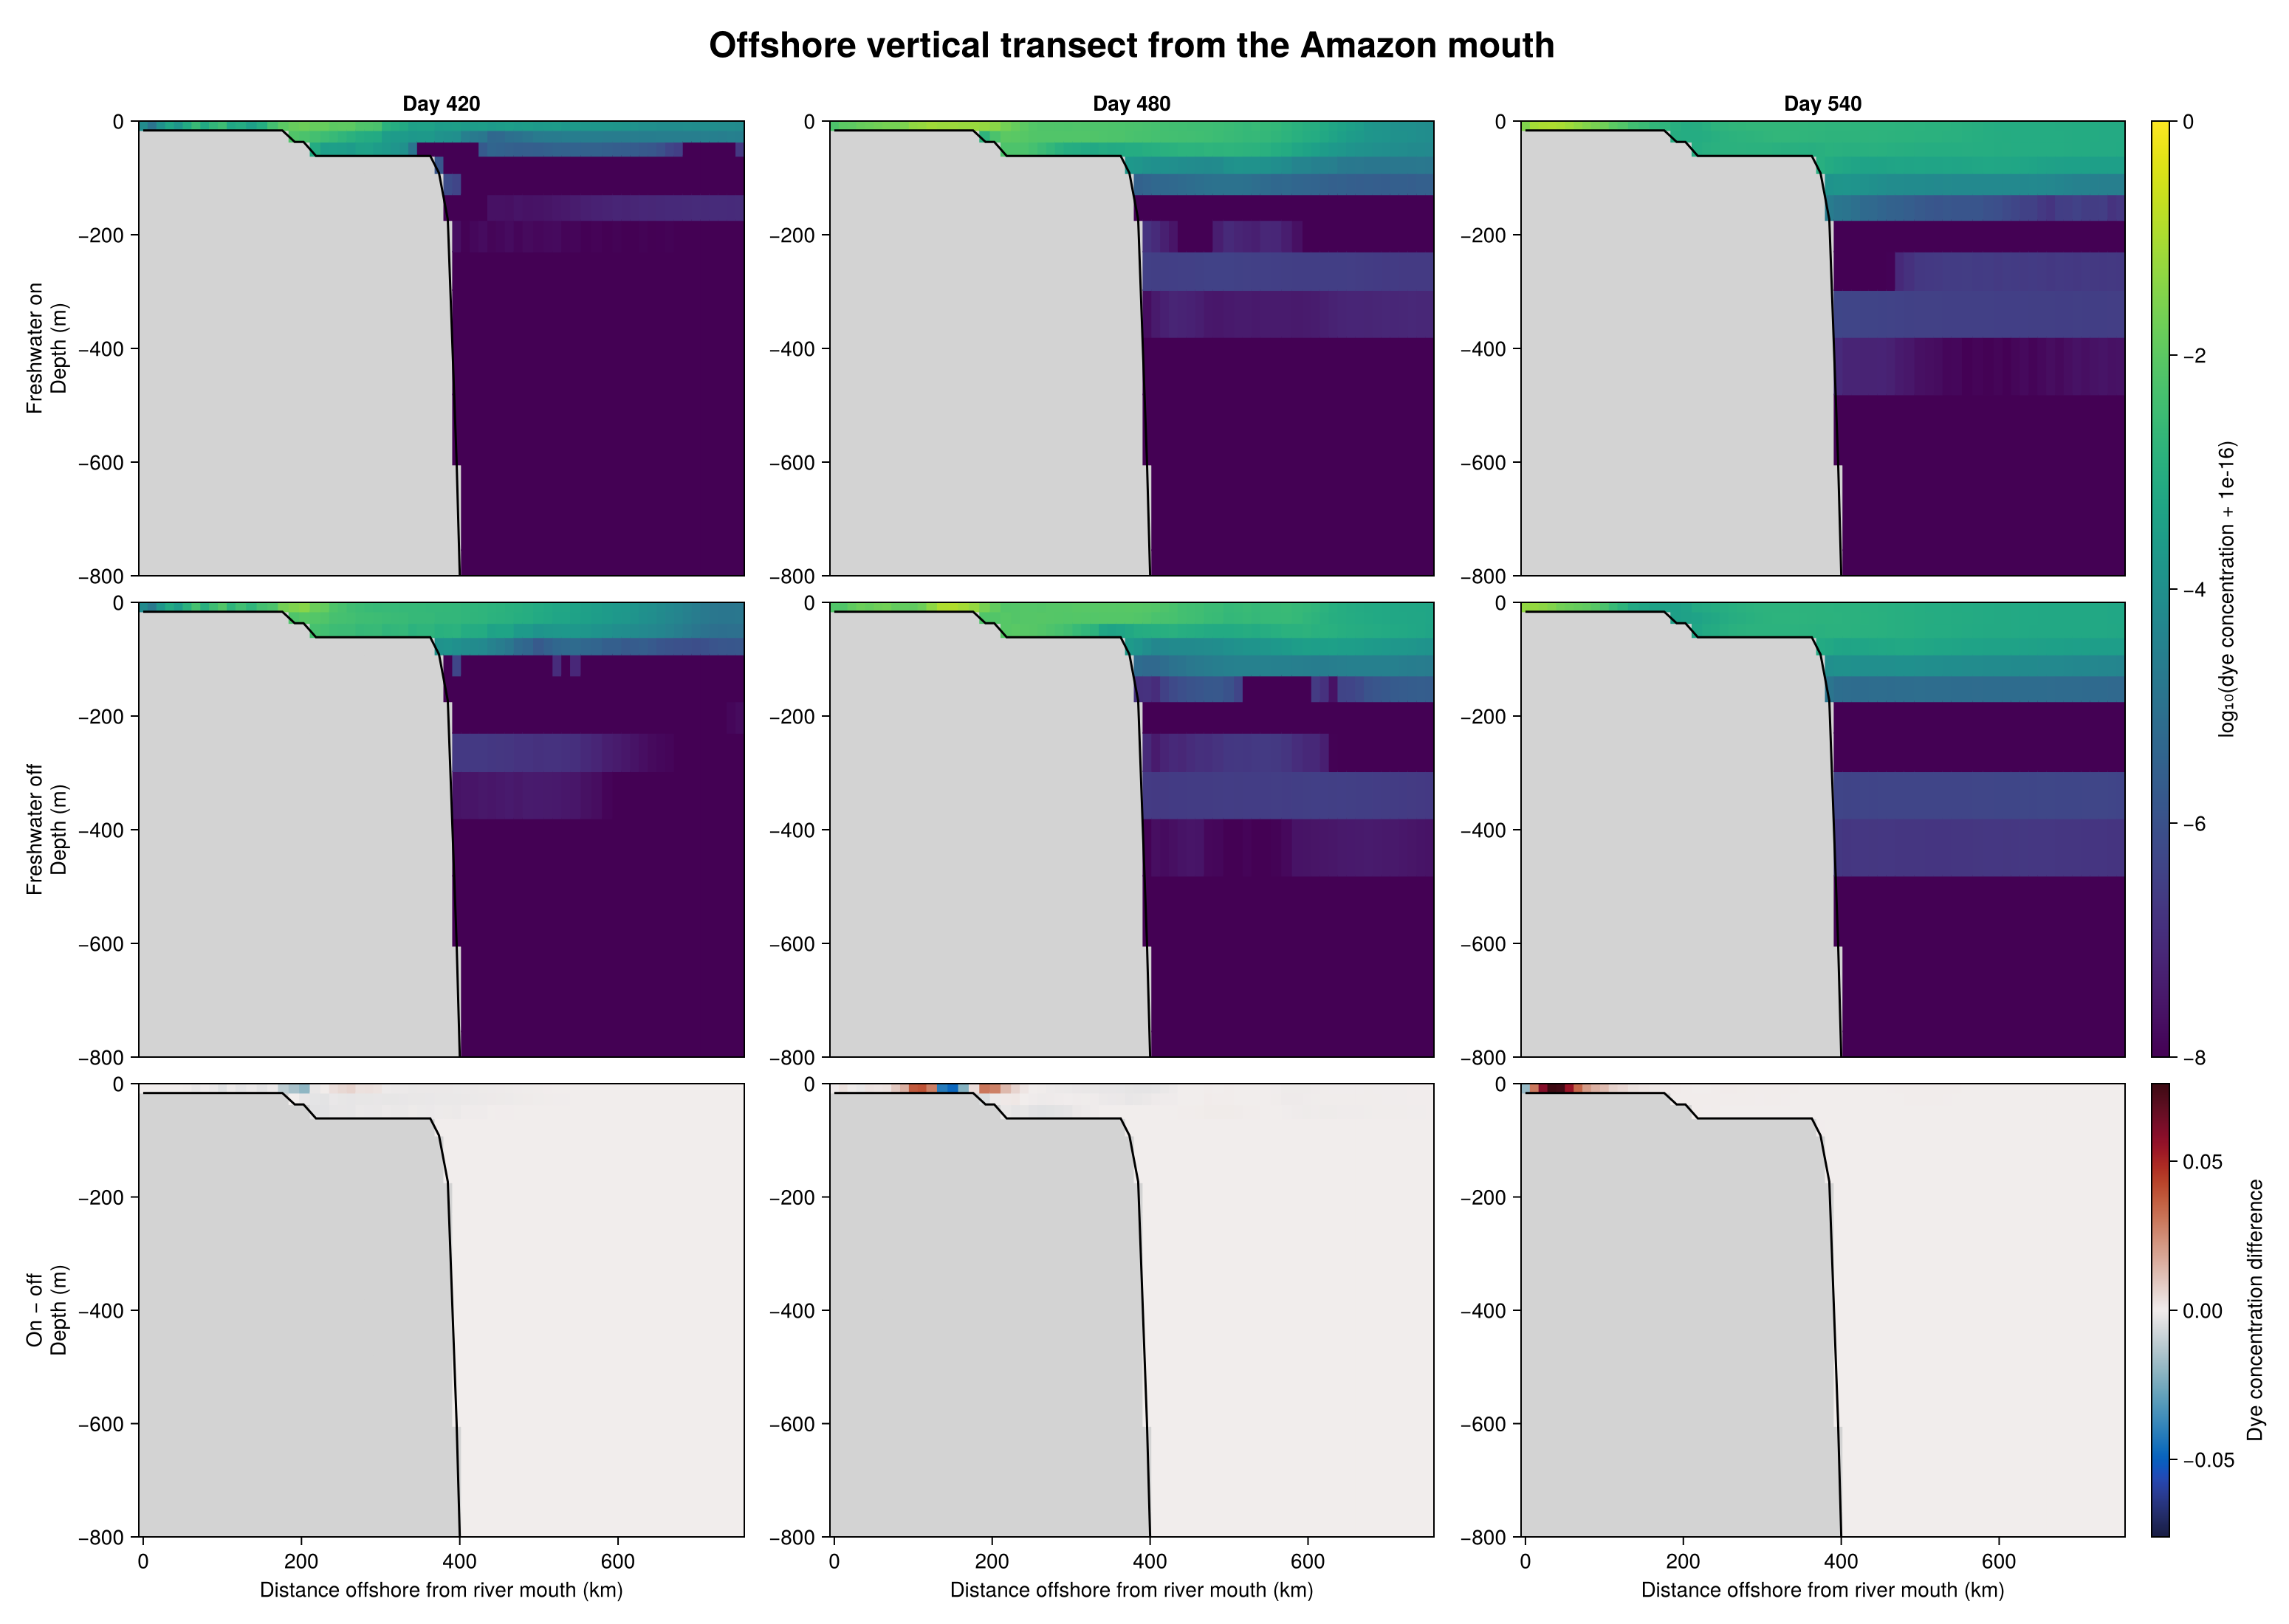

In [ ]:
# offshore transect from the amazon mouth into the open atlantic

# define a path that starts near the river mouth and travels northeast offshore
offshore_start_lon = -49.35
offshore_start_lat = 0.30
offshore_end_lon = -44.65
offshore_end_lat = 2.75

# create evenly spaced points along the requested path
number_of_path_points = 160

requested_lon = range(
    offshore_start_lon,
    offshore_end_lon;
    length = number_of_path_points
)

requested_lat = range(
    offshore_start_lat,
    offshore_end_lat;
    length = number_of_path_points
)

# match every requested point to the nearest model-grid cell
raw_i = [
    argmin(abs.(λ .- longitude))
    for longitude in requested_lon
]

raw_j = [
    argmin(abs.(φ .- latitude))
    for latitude in requested_lat
]

# remove consecutive points that select the same model cell
keep_point = [true;
    (raw_i[2:end] .!= raw_i[1:end-1]) .|
    (raw_j[2:end] .!= raw_j[1:end-1])
]

offshore_i = raw_i[keep_point]
offshore_j = raw_j[keep_point]

# recover the actual model coordinates selected
offshore_lon = λ[offshore_i]
offshore_lat = φ[offshore_j]
number_of_offshore_points = length(offshore_i)

# calculate cumulative distance from the river mouth
offshore_distance_km = zeros(number_of_offshore_points)

for p in 2:number_of_offshore_points
    mean_latitude = deg2rad(
        (offshore_lat[p] + offshore_lat[p-1]) / 2
    )

    dx = 111.32 * cos(mean_latitude) *
         (offshore_lon[p] - offshore_lon[p-1])

    dy = 110.57 *
         (offshore_lat[p] - offshore_lat[p-1])

    offshore_distance_km[p] =
        offshore_distance_km[p-1] + hypot(dx, dy)
end

# extract the seafloor along the offshore path
offshore_bottom = [
    bottom_height[offshore_i[p], offshore_j[p], 1]
    for p in 1:number_of_offshore_points
]

# create containers for all requested days
offshore_log_on_by_day = Any[]
offshore_log_off_by_day = Any[]
offshore_difference_by_day = Any[]
offshore_actual_days_on = Float64[]
offshore_actual_days_off = Float64[]

for target_day in target_days
    # select the saved output closest to the requested day
    time_idx_on = argmin(
        abs.(dye_on.times ./ days .- target_day)
    )

    time_idx_off = argmin(
        abs.(dye_off.times ./ days .- target_day)
    )

    push!(
        offshore_actual_days_on,
        dye_on.times[time_idx_on] / days
    )

    push!(
        offshore_actual_days_off,
        dye_off.times[time_idx_off] / days
    )

    # load and mask the complete three-dimensional dye fields
    field_on = dye_on[time_idx_on]
    field_off = dye_off[time_idx_off]

    mask_immersed_field!(field_on, NaN)
    mask_immersed_field!(field_off, NaN)

    dye_on_3d = Array(interior(field_on))
    dye_off_3d = Array(interior(field_off))

    # allocate distance-along-path × depth arrays
    offshore_transect_on = fill(
        NaN,
        number_of_offshore_points,
        length(z)
    )

    offshore_transect_off = fill(
        NaN,
        number_of_offshore_points,
        length(z)
    )

    # extract the complete vertical column at every offshore position
    for p in 1:number_of_offshore_points
        offshore_transect_on[p, :] .=
            dye_on_3d[offshore_i[p], offshore_j[p], :]

        offshore_transect_off[p, :] .=
            dye_off_3d[offshore_i[p], offshore_j[p], :]
    end

    # calculate log concentrations and the freshwater-on/off difference
    offshore_log_on,
    offshore_log_off,
    offshore_difference = prepare_multitime_transect(
        offshore_transect_on,
        offshore_transect_off
    )

    push!(
        offshore_log_on_by_day,
        offshore_log_on
    )

    push!(
        offshore_log_off_by_day,
        offshore_log_off
    )

    push!(
        offshore_difference_by_day,
        offshore_difference
    )
end

# find one shared symmetric color range for the difference panels
offshore_valid_differences = filter(
    isfinite,
    reduce(
        vcat,
        vec.(offshore_difference_by_day)
    )
)

if isempty(offshore_valid_differences)
    offshore_difference_limit = 1e-16
else
    offshore_difference_limit = maximum(
        abs.(offshore_valid_differences)
    )
end

offshore_difference_limit = max(
    offshore_difference_limit,
    1e-16
)

# create the figure
offshore_figure = Figure(
    size = (1550, 1100)
)

Label(
    offshore_figure[0, 1:length(target_days)],
    "Offshore vertical transect from the Amazon mouth";
    fontsize = 24,
    font = :bold
)

offshore_axes = Axis[]
offshore_concentration_plot = nothing
offshore_difference_plot = nothing

for column in eachindex(target_days)
    actual_day = round(
        Int,
        offshore_actual_days_on[column]
    )

    axis_on = Axis(
        offshore_figure[1, column];
        title = "Day $(actual_day)",
        ylabel = column == 1 ? "Freshwater on\nDepth (m)" : ""
    )

    current_concentration_plot = heatmap!(
        axis_on,
        offshore_distance_km,
        z,
        offshore_log_on_by_day[column];
        colorrange = (-8, 0),
        colormap = :viridis,
        nan_color = :lightgray
    )

    lines!(
        axis_on,
        offshore_distance_km,
        offshore_bottom;
        color = :black,
        linewidth = 1.5
    )

    axis_off = Axis(
        offshore_figure[2, column];
        ylabel = column == 1 ? "Freshwater off\nDepth (m)" : ""
    )

    heatmap!(
        axis_off,
        offshore_distance_km,
        z,
        offshore_log_off_by_day[column];
        colorrange = (-8, 0),
        colormap = :viridis,
        nan_color = :lightgray
    )

    lines!(
        axis_off,
        offshore_distance_km,
        offshore_bottom;
        color = :black,
        linewidth = 1.5
    )

    axis_difference = Axis(
        offshore_figure[3, column];
        xlabel = "Distance offshore from river mouth (km)",
        ylabel = column == 1 ? "On − off\nDepth (m)" : ""
    )

    current_difference_plot = heatmap!(
        axis_difference,
        offshore_distance_km,
        z,
        offshore_difference_by_day[column];
        colorrange = (
            -offshore_difference_limit,
            offshore_difference_limit
        ),
        colormap = :balance,
        nan_color = :lightgray
    )

    lines!(
        axis_difference,
        offshore_distance_km,
        offshore_bottom;
        color = :black,
        linewidth = 1.5
    )

    # show enough depth to see movement beyond the shallow shelf
    ylims!(axis_on, -800, 0)
    ylims!(axis_off, -800, 0)
    ylims!(axis_difference, -800, 0)

    hidexdecorations!(
        axis_on;
        grid = false
    )

    hidexdecorations!(
        axis_off;
        grid = false
    )

    push!(
        offshore_axes,
        axis_on,
        axis_off,
        axis_difference
    )

    if column == 1
        offshore_concentration_plot =
            current_concentration_plot

        offshore_difference_plot =
            current_difference_plot
    end
end

# apply identical axes to every panel
linkxaxes!(offshore_axes...)
linkyaxes!(offshore_axes...)

# add shared colorbars
Colorbar(
    offshore_figure[1:2, length(target_days) + 1],
    offshore_concentration_plot;
    label = "log₁₀(dye concentration + 1e-16)"
)

Colorbar(
    offshore_figure[3, length(target_days) + 1],
    offshore_difference_plot;
    label = "Dye concentration difference"
)

# save and display the completed figure
offshore_filename =
    "amazon_dye_offshore_transect_days_$(join(target_days, '_')).png"

save(
    offshore_filename,
    offshore_figure
)

println("Offshore transect")
println(
    "  transect length: ",
    round(offshore_distance_km[end]; digits = 1),
    " km"
)
offshore_figure

In [ ]:
using CairoMakie
using Oceananigans
using Oceananigans.Units
using Observables

# load full 3d salinity from both simulations
S_on = FieldTimeSeries(
    "amazon_rivers_on_salinity_3d.jld2",
    "S";
    backend = OnDisk()
)

S_off = FieldTimeSeries(
    "amazon_rivers_off_salinity_3d.jld2",
    "S";
    backend = OnDisk()
)

# use only snapshots available in both simulations
Nt = min(length(S_on.times), length(S_off.times))
times = S_on.times[1:Nt]
frame = Observable(1)

# identify the uppermost vertical grid cell
top_layer = size(interior(S_on[1]), 3)

println("rivers-on snapshots: ", length(S_on.times))
println("rivers-off snapshots: ", length(S_off.times))
println("frames being compared: ", Nt)
println("saved days: ", times ./ days)
println("surface layer: ", top_layer)

# calculate rivers-on minus rivers-off surface salinity
salinity_difference = @lift begin
    salinity_on = Array(
        interior(S_on[$frame], :, :, top_layer)
    )

    salinity_off = Array(
        interior(S_off[$frame], :, :, top_layer)
    )

    difference = fill(NaN, size(salinity_on))

    for j in axes(difference, 2)
        for i in axes(difference, 1)
            on_value = salinity_on[i, j]
            off_value = salinity_off[i, j]

            values_are_valid =
                isfinite(on_value) &&
                isfinite(off_value) &&
                on_value > 20 &&
                on_value < 40 &&
                off_value > 20 &&
                off_value < 40

            if values_are_valid
                difference[i, j] = on_value - off_value
            end
        end
    end

    difference
end

# update the title with the current saved day
title = @lift string(
    "Surface salinity difference: rivers on - rivers off, day ",
    round(Int, times[$frame] / days)
)

# create the surface salinity-difference plot
figure = Figure(size = (900, 750))

axis = Axis(
    figure[1, 1],
    title = title,
    xlabel = "Grid x index",
    ylabel = "Grid y index",
    aspect = DataAspect()
)

heatmap_plot = heatmap!(
    axis,
    salinity_difference;
    colorrange = (-0.2, 0.2),
    colormap = :balance,
    nan_color = :lightgray
)

Colorbar(
    figure[1, 2],
    heatmap_plot;
    label = "Salinity difference (g kg^-1)"
)

# save the final shared snapshot
frame[] = Nt

save(
    "amazon_salinity_difference_snapshot.png",
    figure
)

# animate all shared salinity snapshots
CairoMakie.record(
    figure,
    "amazon_salinity_difference.mp4",
    1:Nt;
    framerate = 4
) do current_frame
    frame[] = current_frame
end

figure